# Galaxy Clustering Algorithm!

- Use VFS galaxies! Fortunately, I have not deleted my catalog of galaxies...
- What data?
    - Maybe feed in either CIGALE or GALFIT output parameters?
    - Measure curves of growth??
- Use PCA for dimensionality reduction
- Then...UNSUPERVISED LEARNING! I.E., find natural groupings in the data without pre-defined labels
- And then...interpret. Is there any physical meaning associated with the clusters?
    - Morphology? 
        - May have to perform some visual inspection
        - Could also try statmorph?
    - Environment?
        - vf_v2_environment.fits flags

### To begin, I will need some features
- A few thoughts:
    - NUV-r, FUV-NUV, W1-W3, g-r, W1-W2 colors
    - CIGALE sSFR, Mstar, A_V
    - GALFIT nser (W1), nser (W3), axis ratio (W1), size ratio (W3/W1)
    - W1 luminosity
- Will have to 'standardize' these features for clustering
    - ensures all features contribute equally regardless of their original units and scales

In [ ]:
from astropy.table import Table
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline
import os
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
#pull the data; tidy the data; isolate the features; normalize (or log?) the features
cigale = Table.read('data/cigale_vf_metallicity.fits')
galfit_w1 = Table.read('data/vf_v2_galfit_W1-fixBA.fits')
galfit_w3 = Table.read('data/vf_v2_galfit_W3-fixBA.fits')
phot = Table.read('data/vf_v2_legacy_ephot.fits')
environment = Table.read('data/vf_v2_environment.fits')   #for later

In [ ]:
#cannot have a convolved model which GALFIT has flagged as unreliable...and there is no data in the row,
#which I interpret as the central x pixel being zero.
galfit_quality_check = (~galfit_w1['CNumerical_Error']) & (~galfit_w3['CNumerical_Error']) & \
                       (galfit_w1['CXC']>0) & (galfit_w3['CXC']>0) & \
                       (galfit_w1['CN']<=6) & (galfit_w3['CN']<=6)

In [ ]:
#add CIGALE quality check
#just be sure no empty stellar ass rows
cigale_quality_check = (cigale['bayes.stellar.m_star']>0)

In [ ]:
#add legacy photometry quality check
#amounts to making sure none of the columns we need have empty cells
phot_quality_check = (phot['FLUX_AP03_NUV']>0) & (phot['FLUX_AP03_FUV']>0) & \
                     (phot['FLUX_AP03_R']>0) & (phot['FLUX_AP03_W3']>0) & \
                     (phot['FLUX_AP01_G']>0) & (phot['FLUX_AP01_R']>0) & \
                     (phot['FLUX_SB25_W1']>0) & (phot['FLUX_SB23_W1']>0)

In [ ]:
#defining and applying flags
full_flag = galfit_quality_check #& cigale_quality_check & phot_quality_check
cigale = cigale[full_flag]
galfit_w1 = galfit_w1[full_flag]
galfit_w3 = galfit_w3[full_flag]
phot = phot[full_flag]
environment = environment[full_flag]

---

In [ ]:
##############
# photometry #
##############

#converting to magnitudes, then calculating colors
NUV_R = -2.5*np.log10(phot['FLUX_AP03_NUV']/phot['FLUX_AP03_R']) # SF history
FUV_NUV = -2.5*np.log10(phot['FLUX_AP03_FUV']/phot['FLUX_AP03_NUV']) # Recent SF + dust
G_R = -2.5*np.log10(phot['FLUX_AP03_G']/phot['FLUX_AP03_R']) # Optical color
W1_W2 = -2.5*np.log10(phot['FLUX_AP03_W1']/phot['FLUX_AP03_W2']) # AGN diagnostic
W1_W3 = -2.5*np.log10(phot['FLUX_AP03_W1']/phot['FLUX_AP03_W3']) # SF/AGN activity

#g-r color gradient from nearest to farthest relative to galaxy center
num = (phot['FLUX_AP01_G']/phot['FLUX_AP01_R'])
den = (phot['FLUX_AP08_G']/phot['FLUX_AP08_R'])
color_gradient = num / den

#some W1 surface brightness concentration because why not
concentration_W1 = phot['FLUX_SB23_W1'] / phot['FLUX_SB25_W1']  # Higher = more concentrated

In [ ]:
##########
# GALFIT #
##########

nser_w1 = galfit_w1['CN']
nser_w3 = galfit_w3['CN']
ba_w1 = phot['BA_MOMENT']
size_ratio = np.log10(galfit_w3['CRE']/galfit_w1['CRE'])
mag_w1 = galfit_w1['CMAG']
mag_w3 = galfit_w3['CMAG']

In [ ]:
##########
# CIGALE #
##########

logmstar = np.log10(cigale['bayes.stellar.m_star'])
logssfr = np.log10(cigale['bayes.sfh.sfr']) - np.log10(logmstar)
Av_attenuation = cigale['bayes.attenuation.Av_ISM']
fracAGN = cigale['bayes.agn.fracAGN']

---

---

## K-means!
- Pure field, pure group, and pure cluster only

## K-means automated

In [1]:
#from galfit_kmeans import galfit_kmeans
from kmeans_pipeline import run_kmeans

#set colors=False to use the default GALFIT set of features (Sersic index, effective radius)
#df_scaled = galfit_kmeans(colors=False)

#colors=True will include the following color magnitudes from JM's SGA2020 photometry:
    # NUV-r
    # W1-W3

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

Using average g and r effective radius!
Using average W1 and W2 effective radius!


USING THESE FEATURES: ['CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 'CN_W2', 'CN_W3-fixBA', 'AVG_RE_gr', 
'AVG_RE_W1W2']

#####################################################
Removed 4566/6780 galaxies with GALFIT quality flags.
#####################################################
IQR clipping (k=1.5): Removing an additional 667/2214 outliers (30.1%)
Remaining galaxies: 1547


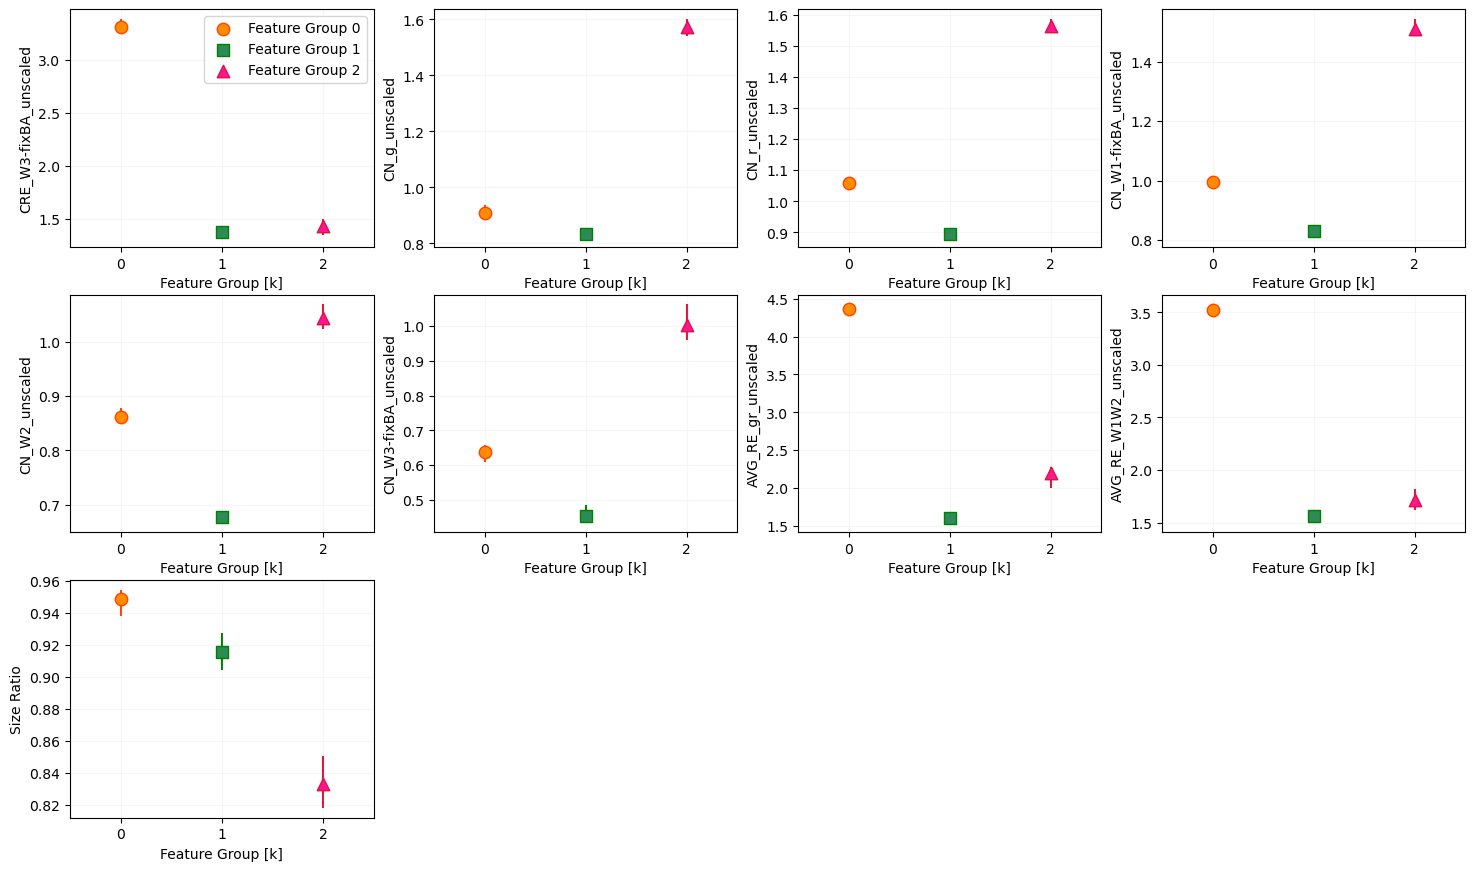

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/kmeans_features.csv:

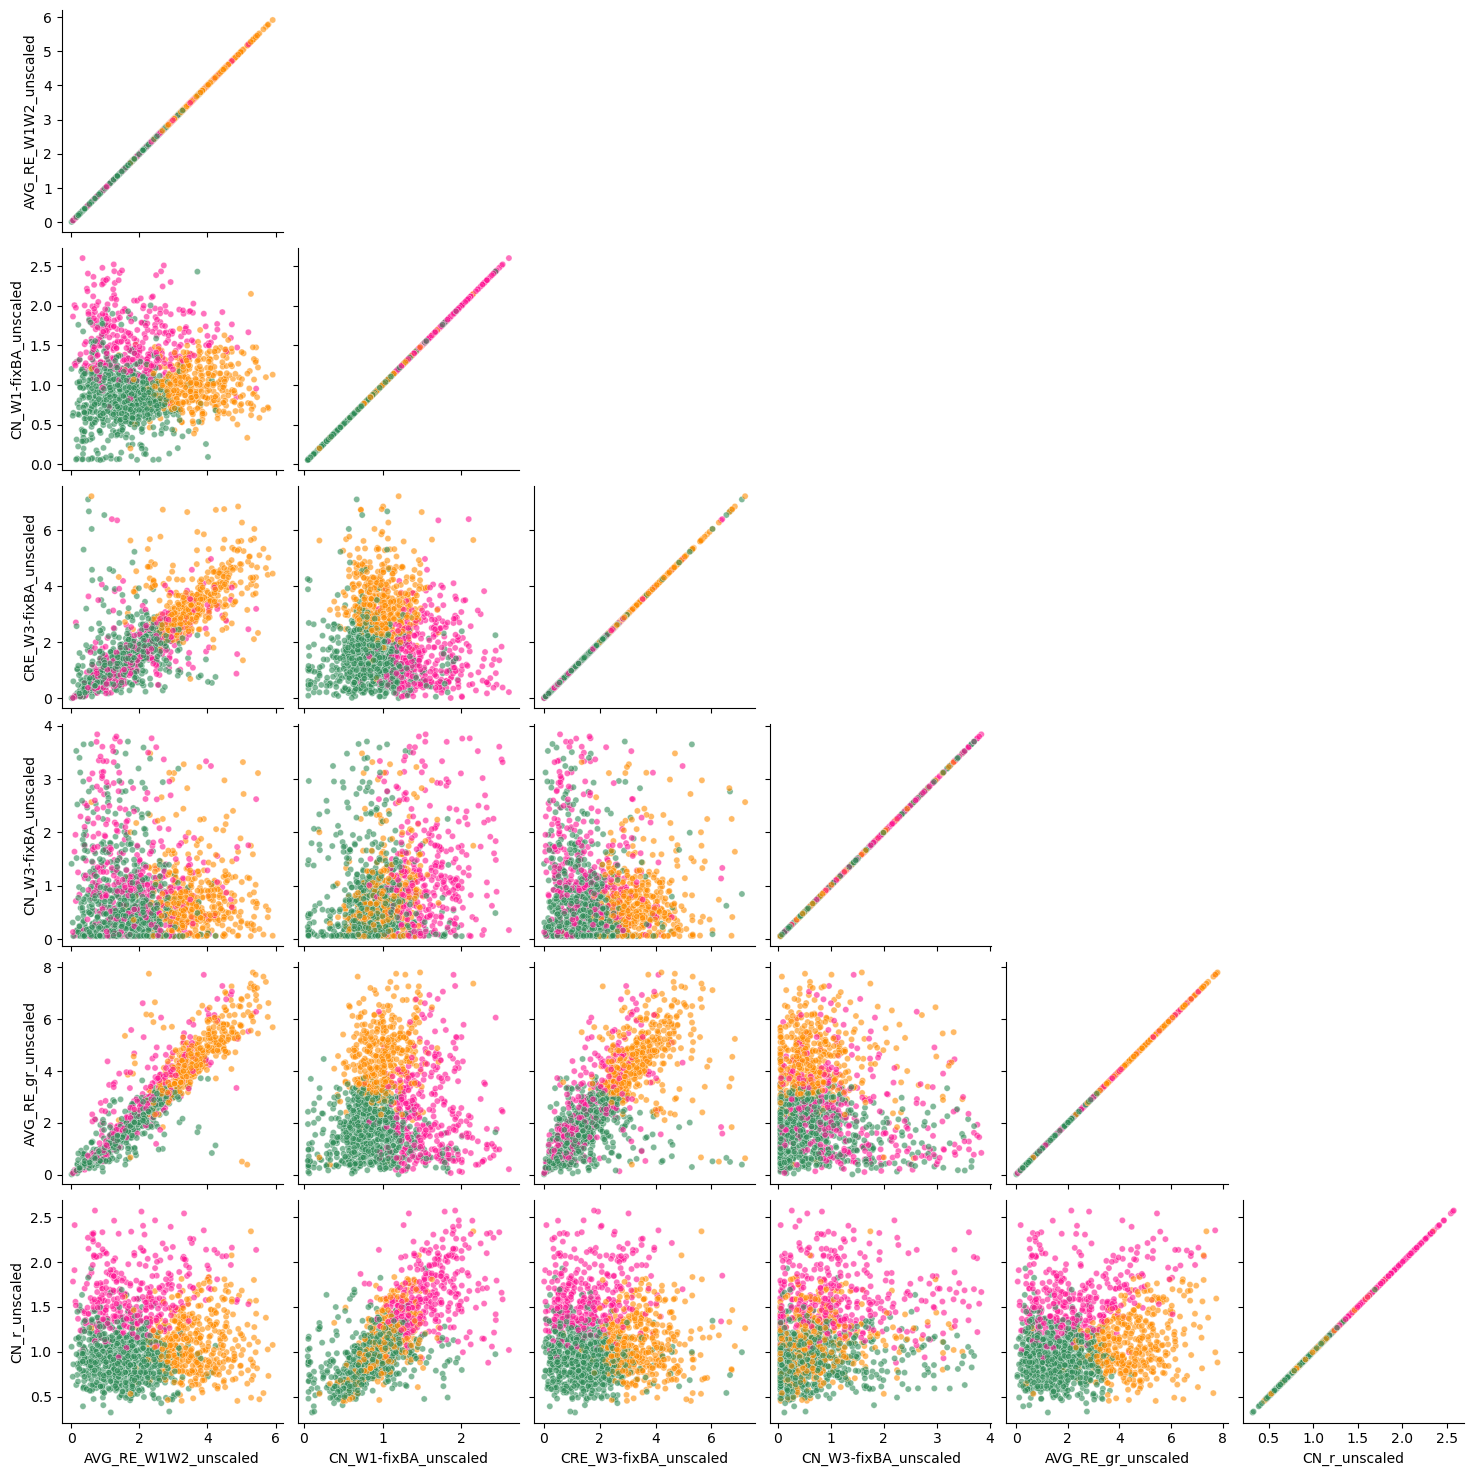

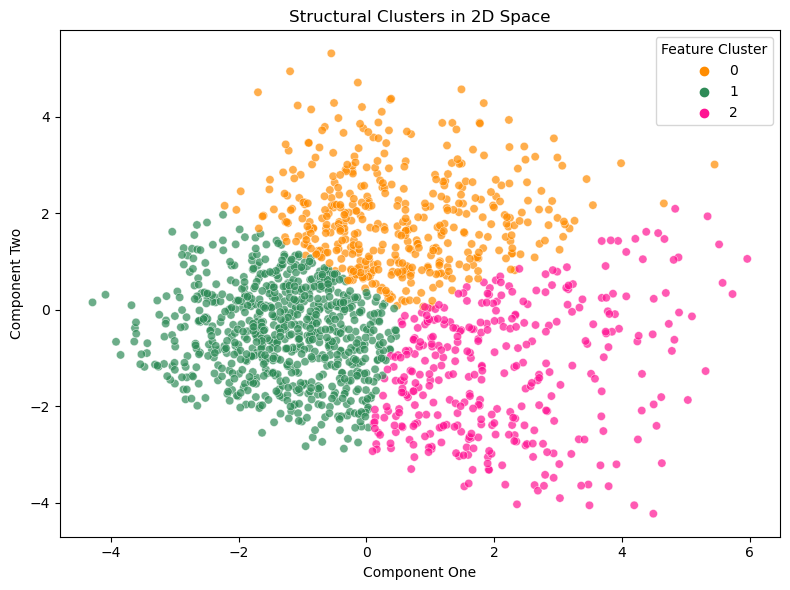

Environment 0 cluster 0: fraction 0.087+/-0.013
Environment 0 cluster 1: fraction 0.134+/-0.012
Environment 0 cluster 2: fraction 0.207+/-0.021
Environment 1 cluster 0: fraction 0.239+/-0.020
Environment 1 cluster 1: fraction 0.210+/-0.015
Environment 1 cluster 2: fraction 0.272+/-0.024
Environment 2 cluster 0: fraction 0.228+/-0.020
Environment 2 cluster 1: fraction 0.178+/-0.014
Environment 2 cluster 2: fraction 0.204+/-0.021
Environment 3 cluster 0: fraction 0.216+/-0.020
Environment 3 cluster 1: fraction 0.334+/-0.017
Environment 3 cluster 2: fraction 0.308+/-0.024
Environment 4 cluster 0: fraction 0.378+/-0.023
Environment 4 cluster 1: fraction 0.354+/-0.017
Environment 4 cluster 2: fraction 0.244+/-0.023


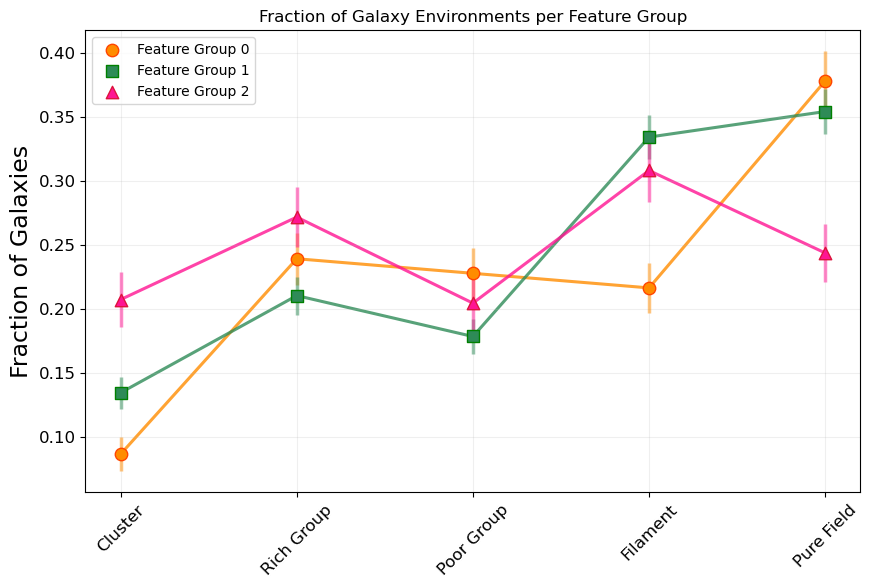

In [6]:
import warnings
warnings.filterwarnings("ignore")

df_scaled_colors = run_kmeans(colors=False, flux=False)

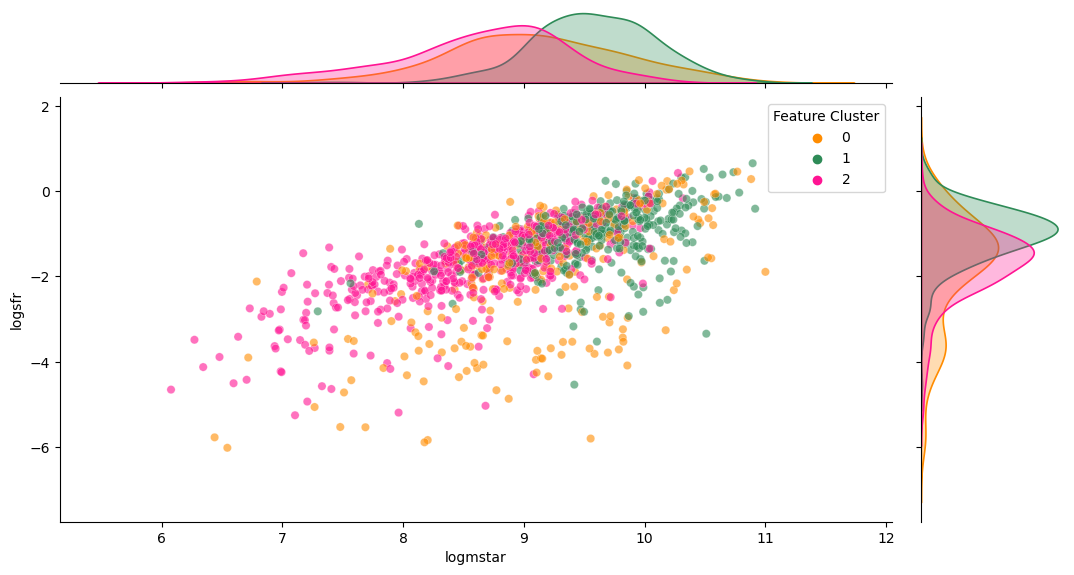

In [3]:
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

palette = ['darkorange', 'seagreen', 'deeppink']

g = sns.JointGrid(data=df_scaled_colors, x="logmstar", y="logsfr", height=5)

# ---- MAIN SCATTER ----
g.plot_joint(sns.scatterplot, data=df_scaled_colors, hue="Feature Cluster", palette=palette, 
             alpha=0.6, edgecolor="w", linewidth=0.3)

# ---- KDE MARGINALS ----
for k, color in enumerate(palette):
    subset = df_scaled_colors[df_scaled_colors["Feature Cluster"] == k]

    #top marginal (logmstar)
    sns.kdeplot(x=subset["logmstar"], ax=g.ax_marg_x, color=color, fill=True, alpha=0.3, linewidth=1.2)

    #right marginal (logsfr)
    sns.kdeplot(y=subset["logsfr"], ax=g.ax_marg_y, color=color, fill=True, alpha=0.3, linewidth=1.2)

g.fig.set_size_inches(12, 6)
plt.show()

In [3]:
from hdbscan_pipeline import run_hdbscan

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

Using average g and r effective radius!
Using average W1 and W2 effective radius!


USING THESE FEATURES: ['CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 'CN_W2', 'CN_W3-fixBA', 'AVG_RE_gr', 
'AVG_RE_W1W2', 'NUV_r', 'W1_W3']

##############################################################
Removed 4785/6780 galaxies with GALFIT and PHOT quality flags.
##############################################################
############################
Best (elbow) min_cluster_size = 18
Best min_samples = 2
Total cluster stability = 0.343
############################


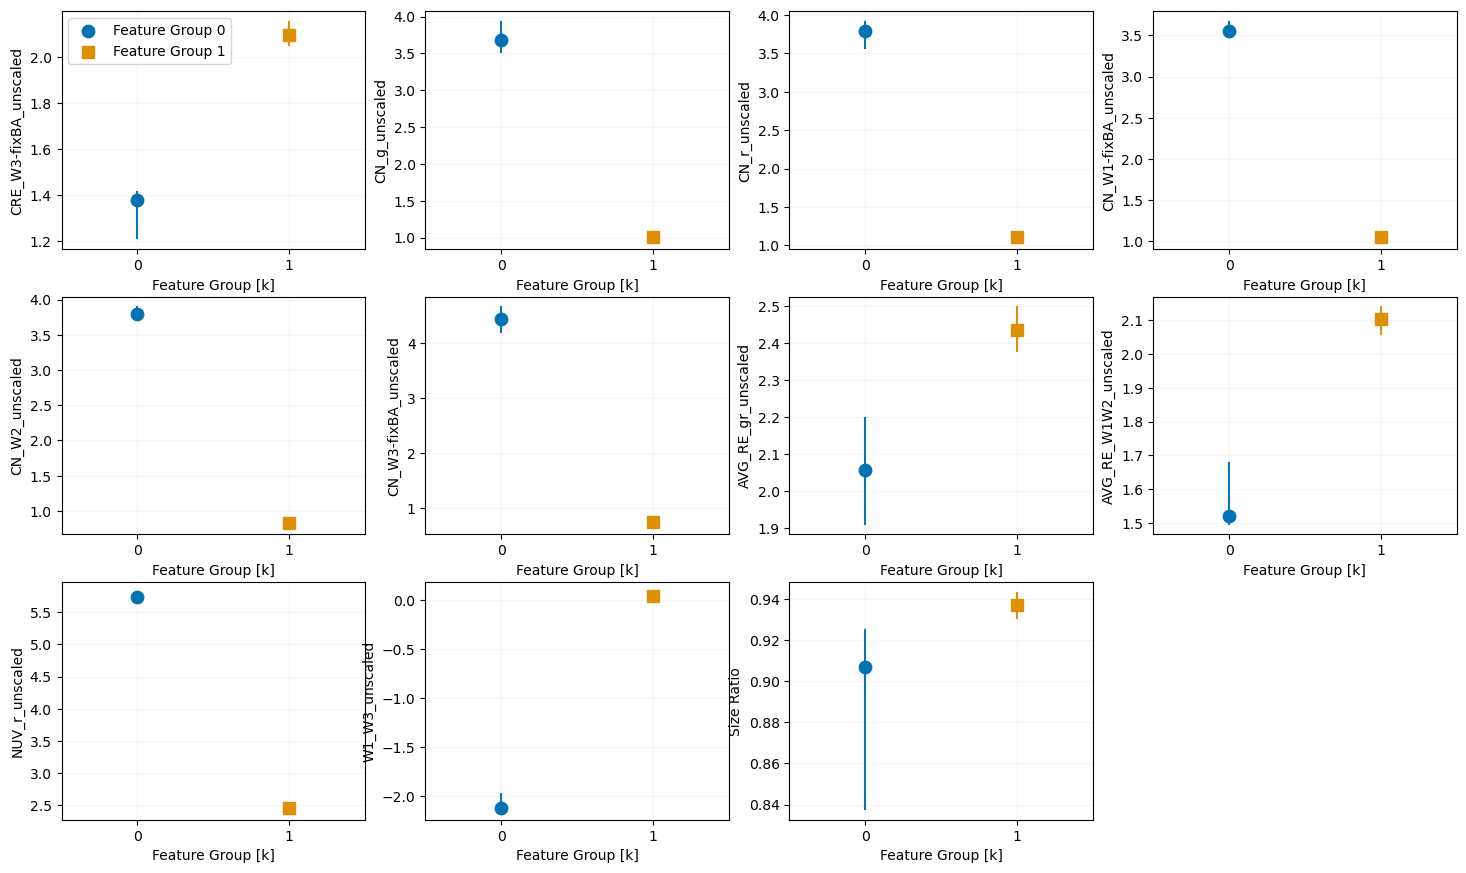

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/hdbscan_features.csv:

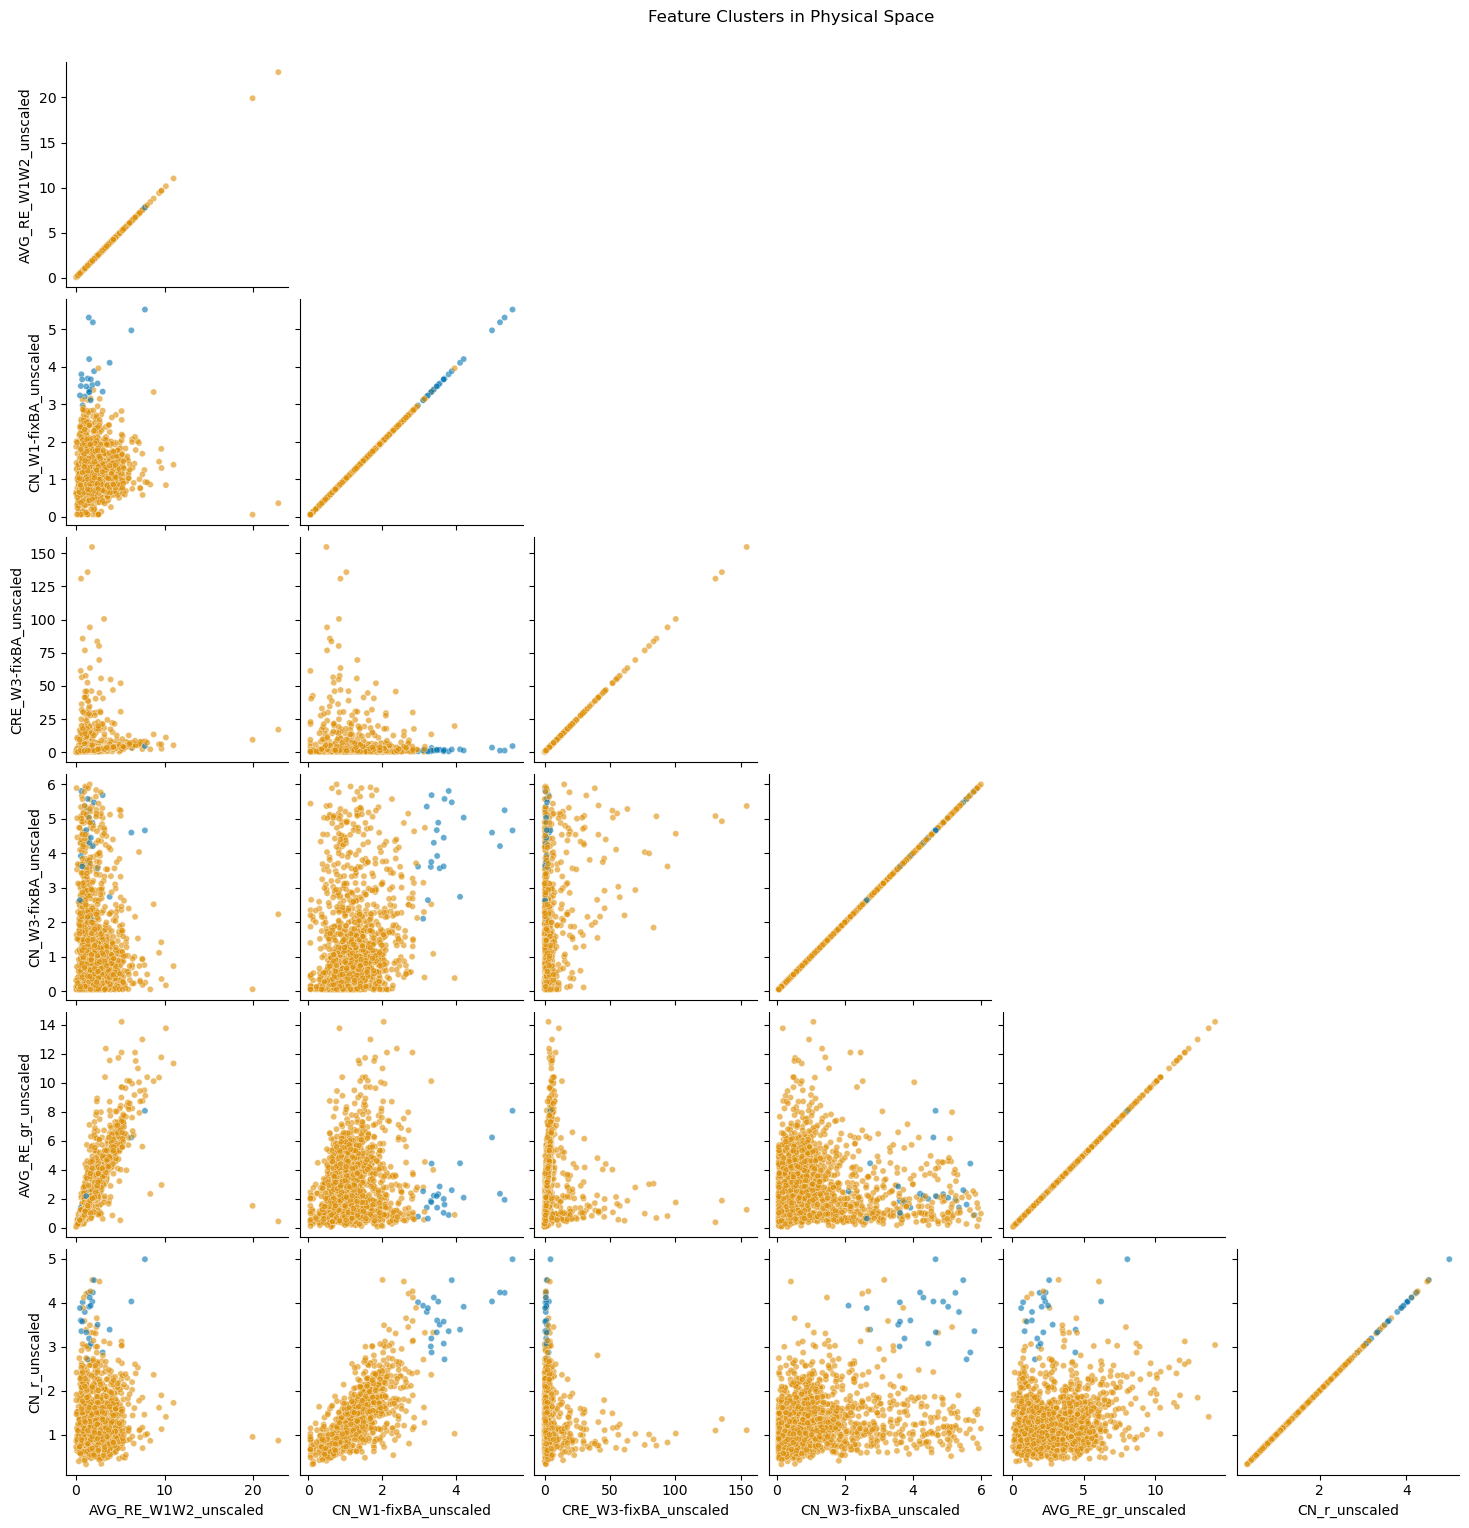

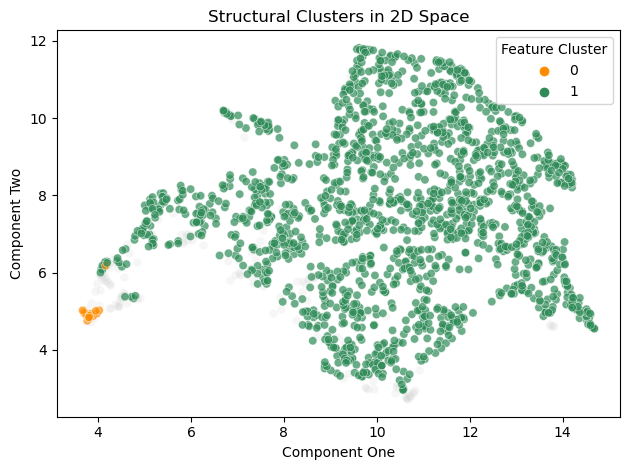

Environment 0 cluster -1: fraction 0.190+/-0.031
Environment 0 cluster 0: fraction 0.565+/-0.103
Environment 0 cluster 1: fraction 0.145+/-0.009
Environment 1 cluster -1: fraction 0.316+/-0.037
Environment 1 cluster 0: fraction 0.261+/-0.092
Environment 1 cluster 1: fraction 0.250+/-0.011
Environment 2 cluster -1: fraction 0.158+/-0.029
Environment 2 cluster 0: fraction 0.174+/-0.079
Environment 2 cluster 1: fraction 0.188+/-0.010
Environment 3 cluster -1: fraction 0.234+/-0.034
Environment 3 cluster 0: fraction 0.174+/-0.079
Environment 3 cluster 1: fraction 0.308+/-0.011
Environment 4 cluster -1: fraction 0.291+/-0.036
Environment 4 cluster 0: fraction 0.000+/-0.000
Environment 4 cluster 1: fraction 0.315+/-0.011


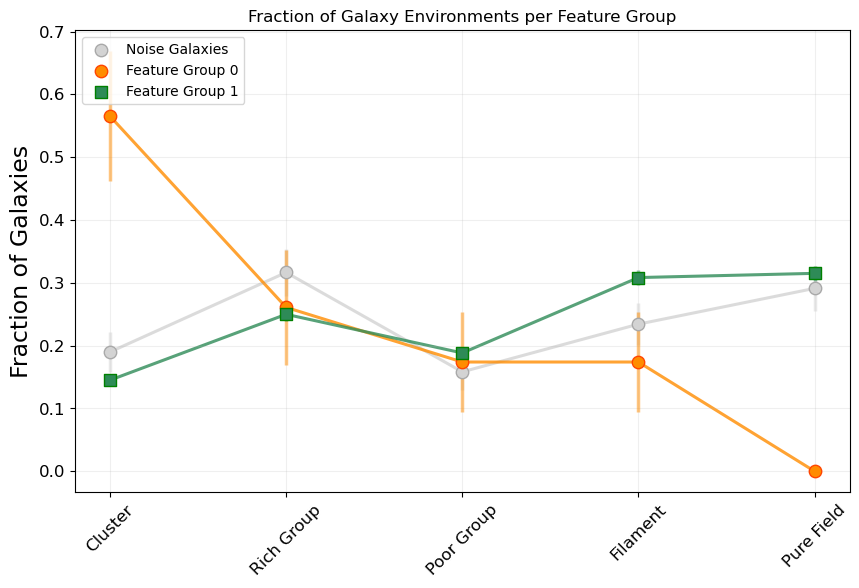

In [4]:
import warnings
warnings.filterwarnings("ignore")

df_scaled = run_hdbscan(colors=True, flux=False)